<a href="https://colab.research.google.com/github/shruti9130/Fundamental/blob/main/analyzing_indian_premier_league_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#1.Basic data exploration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('deliveries.csv.zip')
print(df.head())

   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismissal_kind fielder  
0

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

# 2. Team performance

In [ ]:
team_performance = df.groupby("batting_team")["total_runs"].sum().sort_values(ascending= False)
print("\nTeam Wins:\n",team_performance)


Team Wins:
 batting_team
Mumbai Indians                 42176
Kolkata Knight Riders          39331
Chennai Super Kings            38629
Royal Challengers Bangalore    37692
Rajasthan Royals               34747
Kings XI Punjab                30064
Sunrisers Hyderabad            29071
Delhi Daredevils               24296
Delhi Capitals                 14900
Deccan Chargers                11463
Punjab Kings                    9536
Gujarat Titans                  7757
Lucknow Super Giants            7510
Pune Warriors                   6358
Gujarat Lions                   4862
Royal Challengers Bengaluru     2930
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64


# 3.player of match analysis

In [ ]:
player_performance = df.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
print("\nplayer_performance counts:\n" , player_performance)



player_performance counts:
 batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


# 4.match run distribution

In [ ]:
match_run_distribution = df.groupby("match_id")["total_runs"].sum()
print("\nmatch_run_distribution:\n",match_run_distribution)


match_run_distribution:
 match_id
335982     304
335983     447
335984     261
335985     331
335986     222
          ... 
1426307    429
1426309    323
1426310    346
1426311    314
1426312    227
Name: total_runs, Length: 1095, dtype: int64


# 5.Histogram of team wins

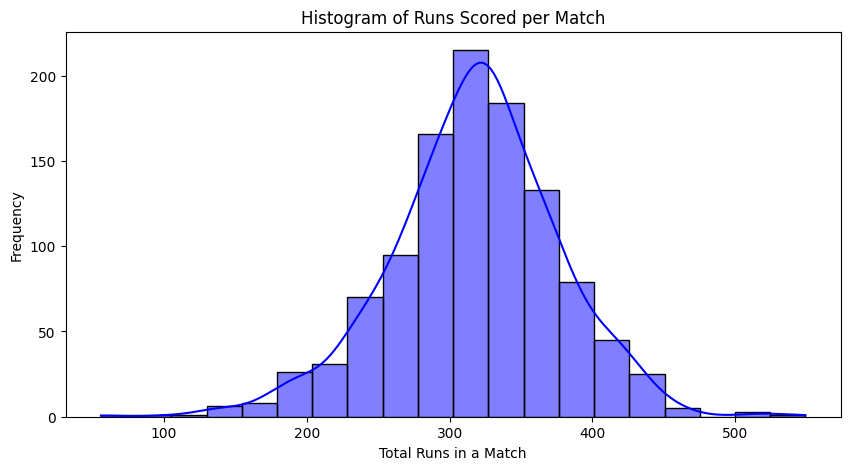

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(match_run_distribution, bins=20, kde=True, color="blue")
plt.title("Histogram of Runs Scored per Match")
plt.xlabel("Total Runs in a Match")
plt.ylabel("Frequency")
plt.show()

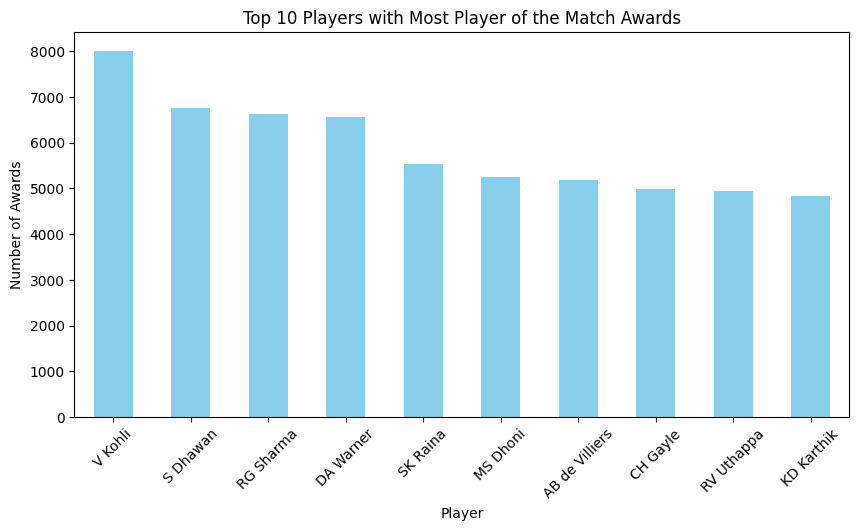

In [ ]:

plt.figure(figsize=(10, 5))
player_performance.plot(kind="bar", color="skyblue")
plt.title("Top 10 Players with Most Player of the Match Awards")
plt.xlabel("Player")
plt.ylabel("Number of Awards")
plt.xticks(rotation=45)
plt.show()
